In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('electronics.csv')
df_clean = df.dropna(subset=['Data_value']).copy()

df_clean['Data_value'] = df_clean['Data_value'].astype(float)
df_clean['Period'] = df_clean['Period'].astype(float)

print(f"Au rămas {len(df_clean)} rânduri valide după curățare.")

Au rămas 21075 rânduri valide după curățare.


In [3]:
df_total = df_clean[df_clean['Series_title_2'] == 'Total'].copy()
df_total = df_total.sort_values(by='Period')

print(df_total[['Period', 'Data_value', 'Series_title_2']].head())

        Period  Data_value Series_title_2
1862   2002.10      2820.0          Total
4178   2002.10      2848.1          Total
14453  2002.10  51981200.0          Total
5879   2002.10      2850.7          Total
4179   2002.11      2784.3          Total


In [4]:
media_tranzactiilor = np.mean(df_total['Data_value'])
mediana_tranzactiilor = np.median(df_total['Data_value'])
valoare_maxima = np.max(df_total['Data_value'])

print(f"Media valorilor: {media_tranzactiilor:.2f}")
print(f"Mediana: {mediana_tranzactiilor:.2f}")
print(f"Maximul: {valoare_maxima:.2f}")

corelatie = df_total['Period'].corr(df_total['Data_value'])
print(f"Coeficientul de corelație: {corelatie:.4f}")

Media valorilor: 43924167.86
Mediana: 5851.20
Maximul: 2113455843.00
Coeficientul de corelație: 0.0903


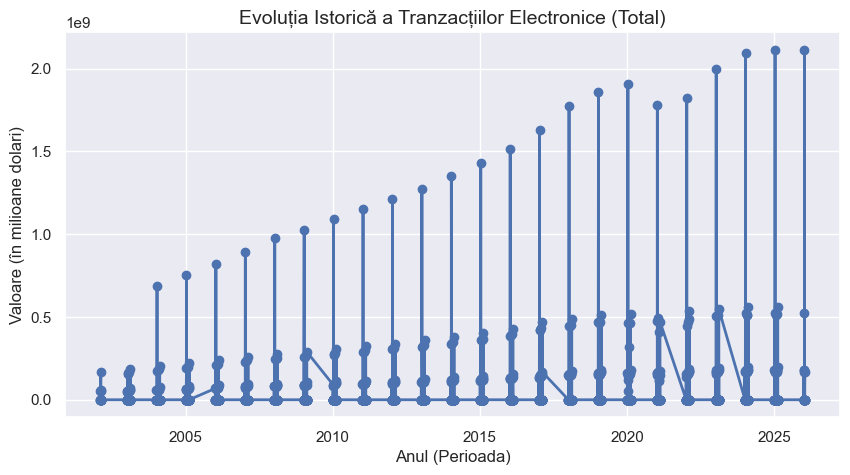

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 5))
plt.plot(df_total['Period'], df_total['Data_value'], marker='o', color='b', linewidth=2)

plt.title('Evoluția Istorică a Tranzacțiilor Electronice (Total)', fontsize=14)
plt.xlabel('Anul (Perioada)', fontsize=12)
plt.ylabel('Valoare (în milioane dolari)', fontsize=12)

plt.savefig('evolutie_tranzactii.png', dpi=300)
plt.show()

In [13]:
industrii_valide = ['Consumables', 'Durables', 'Hospitality', 'Services', 'Apparel']

df_industries = df_clean[df_clean['Series_title_2'].fillna('').str.contains('|'.join(industrii_valide))]
industry_totals = df_industries.groupby('Series_title_2')['Data_value'].sum().sort_values(ascending=False)

print("Topul industriilor determinat corect:")
print(industry_totals)

Topul industriilor determinat corect:
Series_title_2
Consumables    3385555.8
Durables       2371637.8
Hospitality    1623031.4
Apparel         564431.5
Services        445239.5
Name: Data_value, dtype: float64


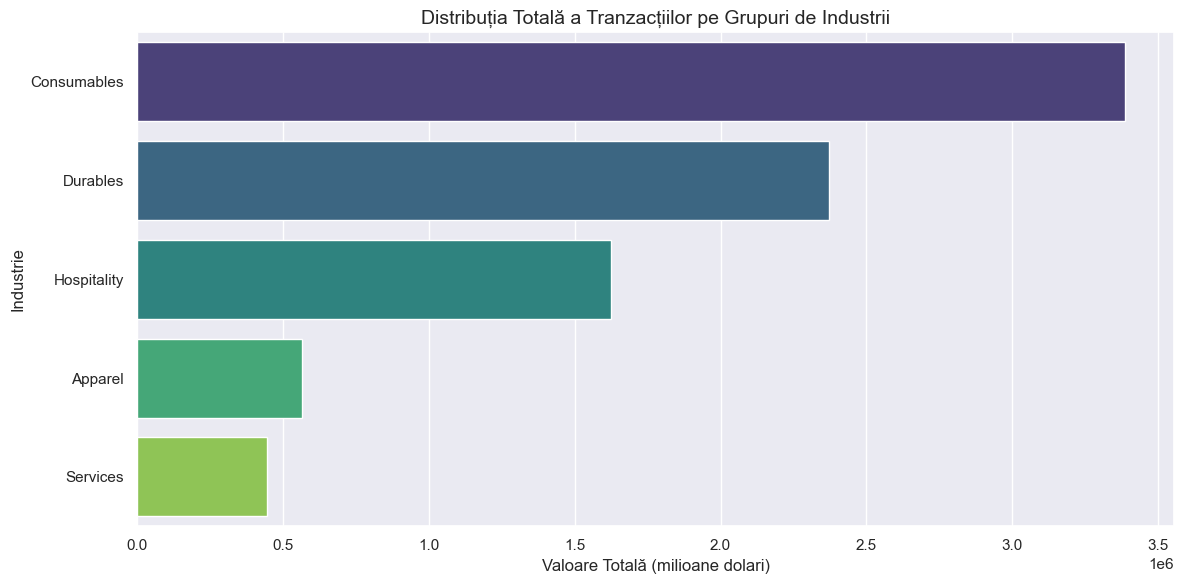

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 6))

sns.barplot(x=industry_totals.values, y=industry_totals.index, hue=industry_totals.index, palette='viridis', legend=False)

plt.title('Distribuția Totală a Tranzacțiilor pe Grupuri de Industrii', fontsize=14)
plt.xlabel('Valoare Totală (milioane dolari)', fontsize=12)
plt.ylabel('Industrie', fontsize=12)

plt.tight_layout()
plt.savefig('distributie_industrii.png', dpi=300)
plt.show()

In [18]:
from scipy import stats

valori_consumables = df_clean[df_clean['Series_title_2'] == 'Consumables']['Data_value']
valori_durables = df_clean[df_clean['Series_title_2'] == 'Durables']['Data_value']

t_stat, p_val = stats.ttest_ind(valori_consumables, valori_durables, equal_var=False)

print(f"Scorul statistic T: {t_stat:.4f}")
print(f"Valoarea P (P-value): {p_val:.6f}")

if p_val < 0.05:
    print("Concluzie: Diferența dintre cele două industrii este semnificativă statistic.")
else:
    print("Concluzie: Nu există o diferență semnificativă statistic între cele două industrii.")

Scorul statistic T: 7.5020
Valoarea P (P-value): 0.000000
Concluzie: Diferența dintre cele două industrii este semnificativă statistic.
